# VAE Models with Bernoulli Likelihood


In [1]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision import datasets, transforms

from vaes.models import VAE, BetaTCVAE, BetaVAE, SparseVAE
from vaes.modules.vae_module import Likelihood

## Data Preparation

Load and preprocess the MNIST dataset.

For demonstration purposes, we use a subset of the data to reduce computation time.


In [2]:
transform = transforms.Compose(
    [
        transforms.ToTensor(),
    ]
)

train_dataset = datasets.MNIST(root='../data', train=True, download=True, transform=transform)

test_dataset = datasets.MNIST(root='../data', train=False, download=True, transform=transform)

n_train_samples = 10000
n_test_samples = 2000

X_train = (train_dataset.data[:n_train_samples].float() / 255.0).reshape(-1, 784).numpy()
X_test = (test_dataset.data[:n_test_samples].float() / 255.0).reshape(-1, 784).numpy()

print(f'Training data shape: {X_train.shape}')
print(f'Test data shape: {X_test.shape}')
print(f'Data range: [{X_train.min():.3f}, {X_train.max():.3f}]')

Training data shape: (10000, 784)
Test data shape: (2000, 784)
Data range: [0.000, 1.000]


## 1. VAE (Variational Autoencoder)

The standard VAE optimizes the following objective function:

$$
\mathcal{L} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - D_{KL}(q(z|x) \| p(z))
$$

where $p(x|z)$ is modeled by a Bernoulli distribution.


In [3]:
vae = VAE(
    input_dim=784,
    hidden_dim=400,
    latent_dim=20,
    likelihood=Likelihood.BERNOULLI,
    epochs=100,
    batch_size=128,
    learning_rate=1e-3,
    verbose=True,
    random_state=42,
)

vae.fit(X_train)

2025-10-28 00:34:32.452 | INFO     | vaes.models.vae:fit:83 - Starting training (epochs=100)
Epoch 1: 100%|██████████| 79/79 [00:00<00:00, 257.59it/s, loss=185.8833, recon=177.1411, kl=8.7422] 
2025-10-28 00:34:32.770 | INFO     | vaes.models.vae:fit:92 - Epoch 1/100 - Loss: 246.0228 (Recon: 237.3044, KL: 8.7184)
Epoch 2: 100%|██████████| 79/79 [00:00<00:00, 260.96it/s, loss=163.0178, recon=151.0951, kl=11.9227]
2025-10-28 00:34:33.075 | INFO     | vaes.models.vae:fit:92 - Epoch 2/100 - Loss: 176.2709 (Recon: 164.3584, KL: 11.9125)
Epoch 3: 100%|██████████| 79/79 [00:00<00:00, 271.08it/s, loss=146.7581, recon=129.8447, kl=16.9134]
2025-10-28 00:34:33.368 | INFO     | vaes.models.vae:fit:92 - Epoch 3/100 - Loss: 152.3867 (Recon: 136.4357, KL: 15.9509)
Epoch 4: 100%|██████████| 79/79 [00:00<00:00, 282.27it/s, loss=126.8822, recon=108.4052, kl=18.4770]
2025-10-28 00:34:33.648 | INFO     | vaes.models.vae:fit:92 - Epoch 4/100 - Loss: 140.9978 (Recon: 122.5856, KL: 18.4123)
Epoch 5: 100%|██

### Training Curves


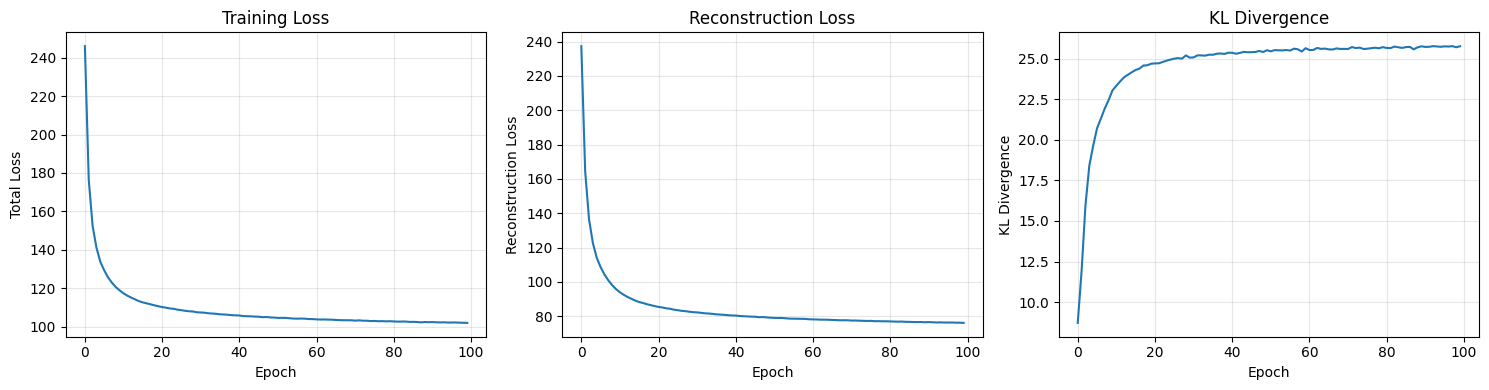

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(vae.history_['train_loss'])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Loss')
axes[0].grid(True, alpha=0.3)

axes[1].plot(vae.history_['train_recon'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss')
axes[1].grid(True, alpha=0.3)

axes[2].plot(vae.history_['train_kl'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/vae_training_curves.png', dpi=300)
plt.show()

### Reconstruction


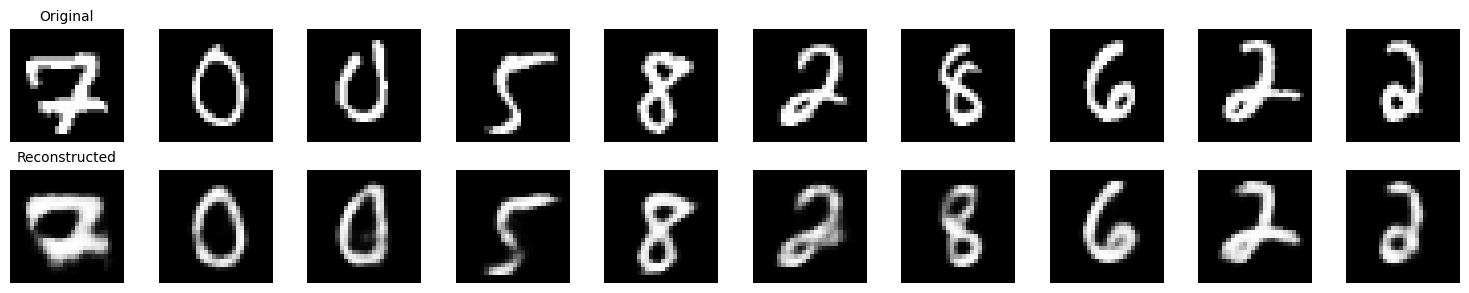

In [5]:
n_samples = 10
indices = np.random.choice(len(X_test), n_samples, replace=False)
X_sample = X_test[indices]
X_recon = vae.reconstruct(X_sample)

fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 1.5, 3))

for i in range(n_samples):
    axes[0, i].imshow(X_sample[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)

    axes[1, i].imshow(X_recon[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=10)

plt.tight_layout()
plt.savefig('../data/vae_reconstruction.png', dpi=300)
plt.show()

### Sampling from Latent Space


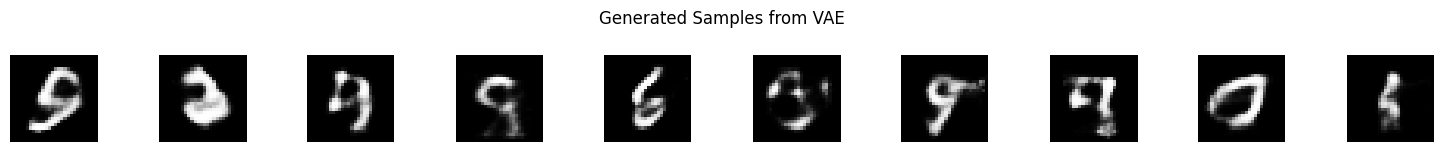

In [6]:
n_samples = 10
X_generated = vae.sample(n_samples)

fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.5, 1.5))

for i in range(n_samples):
    axes[i].imshow(X_generated[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')

plt.suptitle('Generated Samples from VAE')
plt.tight_layout()
plt.savefig('../data/vae_generated_samples.png', dpi=300)
plt.show()

## 2. Beta-VAE

Beta-VAE introduces a weight $\beta$ on the KL term to learn more interpretable latent representations:

$$
\mathcal{L} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - \beta D_{KL}(q(z|x) \| p(z))
$$

Setting $\beta > 1$ encourages independence between latent variables.


In [7]:
beta_vae = BetaVAE(
    input_dim=784,
    hidden_dim=400,
    latent_dim=20,
    likelihood=Likelihood.BERNOULLI,
    beta=4.0,
    epochs=100,
    batch_size=128,
    learning_rate=1e-3,
    verbose=True,
    random_state=42,
)

beta_vae.fit(X_train)

2025-10-28 00:35:04.448 | INFO     | vaes.models.vae:fit:83 - Starting training (epochs=100)
Epoch 1: 100%|██████████| 79/79 [00:00<00:00, 288.69it/s, loss=193.5765, recon=186.3868, kl=1.7974]
2025-10-28 00:35:04.722 | INFO     | vaes.models.vae:fit:92 - Epoch 1/100 - Loss: 253.1341 (Recon: 244.8774, KL: 2.0642)
Epoch 2: 100%|██████████| 79/79 [00:00<00:00, 271.70it/s, loss=179.6556, recon=168.1601, kl=2.8739]
2025-10-28 00:35:05.014 | INFO     | vaes.models.vae:fit:92 - Epoch 2/100 - Loss: 195.9891 (Recon: 184.7309, KL: 2.8146)
Epoch 3: 100%|██████████| 79/79 [00:00<00:00, 297.73it/s, loss=183.0350, recon=161.7862, kl=5.3122]
2025-10-28 00:35:05.281 | INFO     | vaes.models.vae:fit:92 - Epoch 3/100 - Loss: 182.6601 (Recon: 164.4804, KL: 4.5449)
Epoch 4: 100%|██████████| 79/79 [00:00<00:00, 266.43it/s, loss=163.5467, recon=140.1012, kl=5.8614]
2025-10-28 00:35:05.579 | INFO     | vaes.models.vae:fit:92 - Epoch 4/100 - Loss: 177.1558 (Recon: 155.2186, KL: 5.4843)
Epoch 5: 100%|█████████

### Training Curves


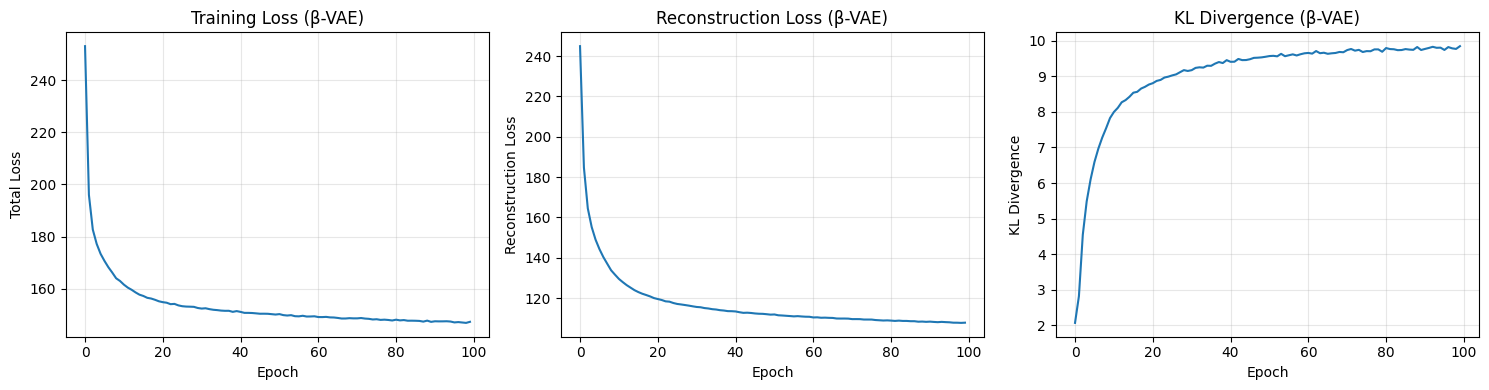

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(beta_vae.history_['train_loss'])
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Total Loss')
axes[0].set_title('Training Loss (β-VAE)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(beta_vae.history_['train_recon'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Reconstruction Loss')
axes[1].set_title('Reconstruction Loss (β-VAE)')
axes[1].grid(True, alpha=0.3)

axes[2].plot(beta_vae.history_['train_kl'])
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_title('KL Divergence (β-VAE)')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/beta_vae_training_curves.png', dpi=300)
plt.show()

### Reconstruction


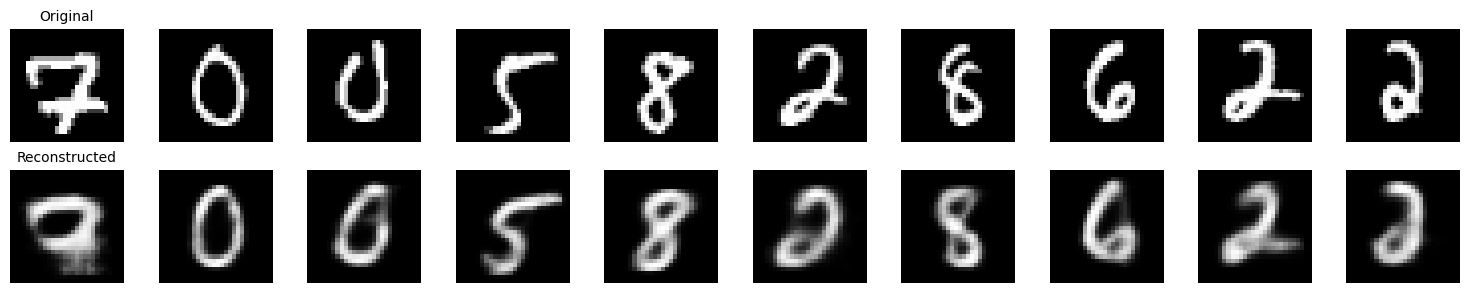

In [9]:
X_recon_beta = beta_vae.reconstruct(X_sample)

fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 1.5, 3))

for i in range(n_samples):
    axes[0, i].imshow(X_sample[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)

    axes[1, i].imshow(X_recon_beta[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=10)

plt.tight_layout()
plt.savefig('../data/beta_vae_reconstruction.png', dpi=300)
plt.show()

### Sampling from Latent Space


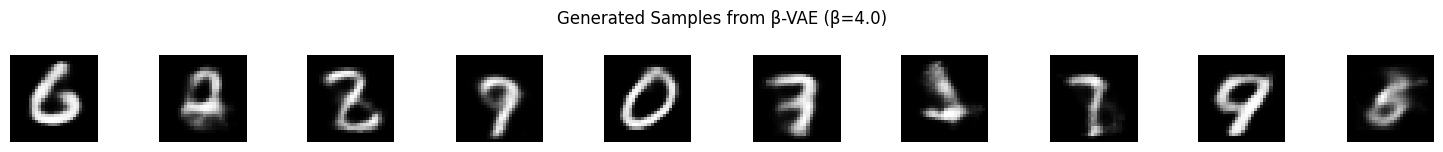

In [10]:
X_generated_beta = beta_vae.sample(n_samples)

fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.5, 1.5))

for i in range(n_samples):
    axes[i].imshow(X_generated_beta[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')

plt.suptitle('Generated Samples from β-VAE (β=4.0)')
plt.tight_layout()
plt.savefig('../data/beta_vae_generated_samples.png', dpi=300)
plt.show()

## 3. Beta-TC-VAE

Beta-TC-VAE decomposes the KL term into three components:

$$
\mathcal{L} = \mathbb{E}_{q(z|x)}[\log p(x|z)] - (\alpha I(z;x) + \beta \text{TC}(z) + \gamma \sum_j D_{KL}(q(z_j) \| p(z_j)))
$$

where:

- $I(z;x)$: Mutual Information
- $\text{TC}(z)$: Total Correlation
- $D_{KL}(q(z_j) \| p(z_j))$: Dimension-wise KL divergence

Increasing $\beta$ encourages independence between latent variables.


In [11]:
beta_tcvae = BetaTCVAE(
    input_dim=784,
    hidden_dim=400,
    latent_dim=20,
    likelihood=Likelihood.BERNOULLI,
    alpha=1.0,
    beta=6.0,
    gamma=1.0,
    epochs=100,
    batch_size=128,
    learning_rate=1e-3,
    verbose=True,
    random_state=42,
)

beta_tcvae.fit(X_train)

2025-10-28 00:35:34.228 | INFO     | vaes.models.beta_tcvae:fit:132 - Starting training (epochs=100, α=1.0, β=6.0, γ=1.0)
Epoch 1: 100%|██████████| 79/79 [00:00<00:00, 170.88it/s, loss=191.8095, recon=183.0984, mi=1.2907, tc=0.5493, dwkl=4.1248]  
2025-10-28 00:35:34.691 | INFO     | vaes.models.beta_tcvae:fit:143 - Epoch 1/100 - Loss: 247.0012 (Recon: 238.1290, MI: 0.6075, TC: 0.2219, DW-KL: 6.9332)
Epoch 2: 100%|██████████| 79/79 [00:00<00:00, 166.87it/s, loss=171.0129, recon=155.7811, mi=2.1476, tc=1.5791, dwkl=3.6096]
2025-10-28 00:35:35.166 | INFO     | vaes.models.beta_tcvae:fit:143 - Epoch 2/100 - Loss: 188.0862 (Recon: 177.2939, MI: 2.5958, TC: 0.8506, DW-KL: 3.0931)
Epoch 3: 100%|██████████| 79/79 [00:00<00:00, 165.18it/s, loss=158.8687, recon=137.4988, mi=2.3364, tc=2.5215, dwkl=3.9046]
2025-10-28 00:35:35.645 | INFO     | vaes.models.beta_tcvae:fit:143 - Epoch 3/100 - Loss: 171.8293 (Recon: 157.9225, MI: 3.6317, TC: 1.3073, DW-KL: 2.4315)
Epoch 4: 100%|██████████| 79/79 [00:

### Training Curves


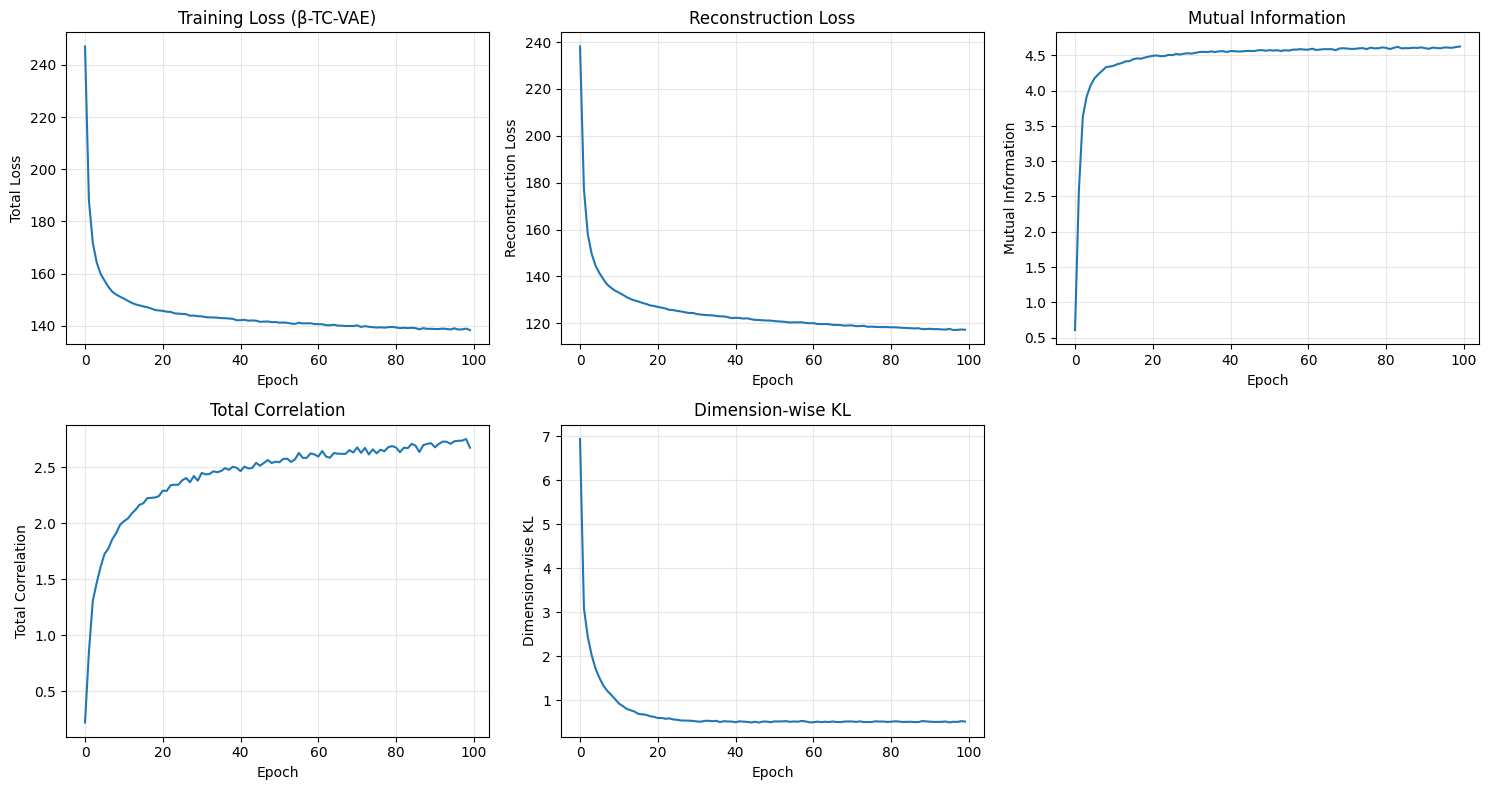

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].plot(beta_tcvae.history_['train_loss'])
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Training Loss (β-TC-VAE)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(beta_tcvae.history_['train_recon'])
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].grid(True, alpha=0.3)

axes[0, 2].plot(beta_tcvae.history_['train_kl'])
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('Mutual Information')
axes[0, 2].set_title('Mutual Information')
axes[0, 2].grid(True, alpha=0.3)

axes[1, 0].plot(beta_tcvae.history_['train_tc'])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Total Correlation')
axes[1, 0].set_title('Total Correlation')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(beta_tcvae.history_['train_dwkl'])
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Dimension-wise KL')
axes[1, 1].set_title('Dimension-wise KL')
axes[1, 1].grid(True, alpha=0.3)

axes[1, 2].axis('off')

plt.tight_layout()
plt.savefig('../data/beta_tcvae_training_curves.png', dpi=300)
plt.show()

### Reconstruction


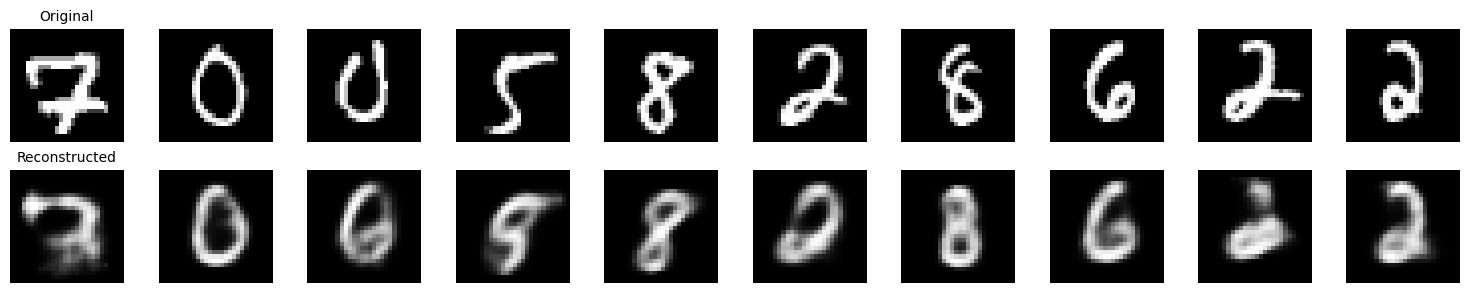

In [13]:
X_recon_btcvae = beta_tcvae.reconstruct(X_sample)

fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 1.5, 3))

for i in range(n_samples):
    axes[0, i].imshow(X_sample[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)

    axes[1, i].imshow(X_recon_btcvae[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=10)

plt.tight_layout()
plt.savefig('../data/beta_tcvae_reconstruction.png', dpi=300)
plt.show()

### Sampling from Latent Space


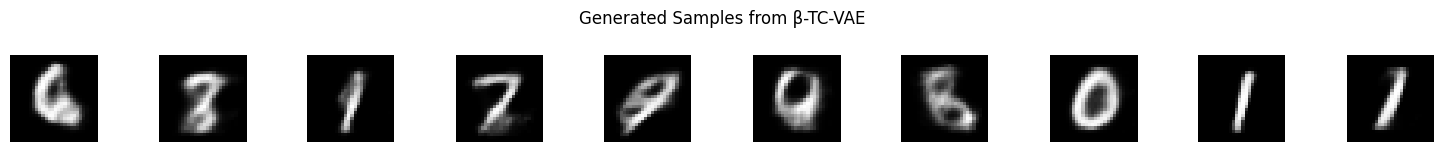

In [14]:
X_generated_btcvae = beta_tcvae.sample(n_samples)

fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.5, 1.5))

for i in range(n_samples):
    axes[i].imshow(X_generated_btcvae[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')

plt.suptitle('Generated Samples from β-TC-VAE')
plt.tight_layout()
plt.savefig('../data/beta_tcvae_generated_samples.png', dpi=300)
plt.show()

## 4. Sparse VAE

Sparse VAE promotes sparsity in the latent variables by introducing gate variables $s_j \in \{0, 1\}$ for each latent variable:

$$
z_j = s_j \cdot \tilde{z}_j
$$

where $\tilde{z}_j \sim \mathcal{N}(\mu_j, \sigma_j^2)$ and $s_j \sim \text{Bernoulli}(\pi)$.

The objective function is:

$$
\mathcal{L} = \mathbb{E}_{q(z,s|x)}[\log p(x|z)] - \beta D_{KL}(q(z|x,s) \| p(z)) - D_{KL}(q(s|x) \| p(s))
$$


In [15]:
sparse_vae = SparseVAE(
    input_dim=784,
    hidden_dim=400,
    latent_dim=20,
    likelihood=Likelihood.BERNOULLI,
    sparsity_prior=0.5,
    beta=1.0,
    epochs=100,
    batch_size=128,
    learning_rate=1e-3,
    verbose=True,
    random_state=42,
)

sparse_vae.fit(X_train)

2025-10-28 00:36:22.087 | INFO     | vaes.models.sparse_vae:fit:90 - Starting training (epochs=100, sparsity_prior=0.5)
Epoch 1: 100%|██████████| 79/79 [00:00<00:00, 245.13it/s, loss=197.4033, recon=189.9921, kl_z=6.7648, kl_s=0.6464] 
2025-10-28 00:36:22.411 | INFO     | vaes.models.sparse_vae:fit:102 - Epoch 1/100 - Loss: 253.0257 (Recon: 242.9036, KL_z: 8.5771, KL_s: 1.5449)
Epoch 2: 100%|██████████| 79/79 [00:00<00:00, 251.09it/s, loss=158.7371, recon=146.6904, kl_z=11.2935, kl_s=0.7532]
2025-10-28 00:36:22.727 | INFO     | vaes.models.sparse_vae:fit:102 - Epoch 2/100 - Loss: 180.1518 (Recon: 169.0625, KL_z: 10.2489, KL_s: 0.8404)
Epoch 3: 100%|██████████| 79/79 [00:00<00:00, 240.88it/s, loss=158.1860, recon=143.1651, kl_z=14.0055, kl_s=1.0153]
2025-10-28 00:36:23.056 | INFO     | vaes.models.sparse_vae:fit:102 - Epoch 3/100 - Loss: 156.3549 (Recon: 142.5487, KL_z: 12.8554, KL_s: 0.9507)
Epoch 4: 100%|██████████| 79/79 [00:00<00:00, 231.34it/s, loss=141.7737, recon=124.9196, kl_z=1

### Training Curves


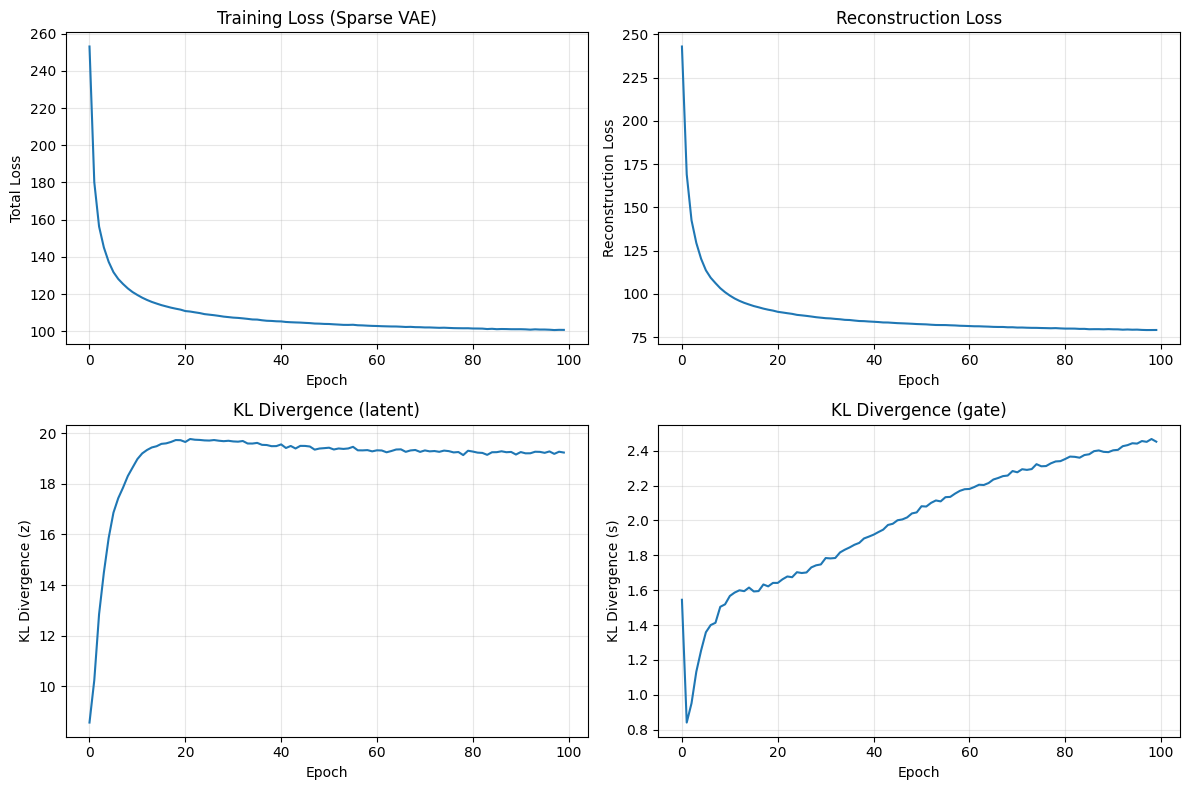

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].plot(sparse_vae.history_['train_loss'])
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Total Loss')
axes[0, 0].set_title('Training Loss (Sparse VAE)')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(sparse_vae.history_['train_recon'])
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Reconstruction Loss')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(sparse_vae.history_['train_kl_z'])
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('KL Divergence (z)')
axes[1, 0].set_title('KL Divergence (latent)')
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(sparse_vae.history_['train_kl_s'])
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('KL Divergence (s)')
axes[1, 1].set_title('KL Divergence (gate)')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/sparse_vae_training_curves.png', dpi=300)
plt.show()

### Sparsity Analysis


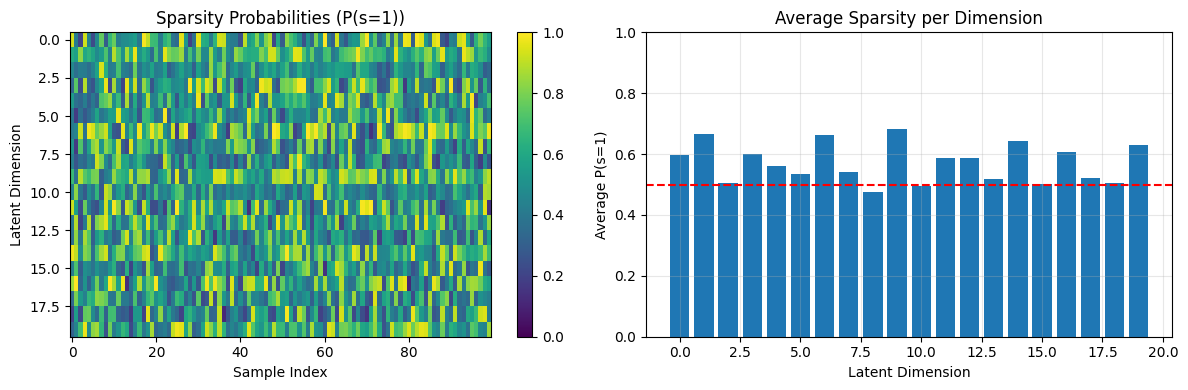

Average sparsity: 0.571
Number of active dimensions (P(s=1) > 0.5): 18/20


In [17]:
sparsity_probs = sparse_vae.get_sparsity(X_test[:100])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im = axes[0].imshow(sparsity_probs.T, aspect='auto', cmap='viridis', vmin=0, vmax=1)
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Latent Dimension')
axes[0].set_title('Sparsity Probabilities (P(s=1))')
plt.colorbar(im, ax=axes[0])

avg_sparsity = sparsity_probs.mean(axis=0)
axes[1].bar(range(len(avg_sparsity)), avg_sparsity)
axes[1].axhline(y=0.5, color='r', linestyle='--', label='Prior (0.5)')
axes[1].set_xlabel('Latent Dimension')
axes[1].set_ylabel('Average P(s=1)')
axes[1].set_title('Average Sparsity per Dimension')
axes[1].set_ylim([0, 1])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/sparse_vae_sparsity.png', dpi=300)
plt.show()

print(f'Average sparsity: {sparsity_probs.mean():.3f}')
print(
    f'Number of active dimensions (P(s=1) > 0.5): {(avg_sparsity > 0.5).sum()}/{len(avg_sparsity)}'
)

### Reconstruction


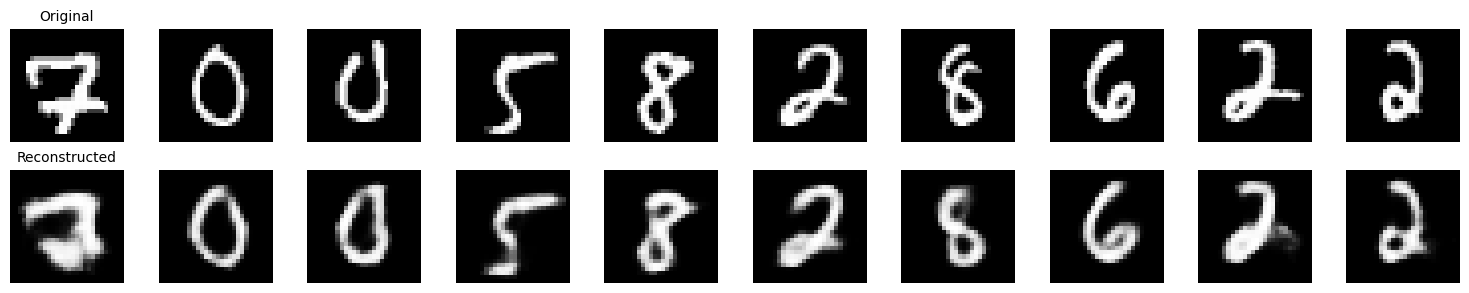

In [18]:
X_recon_sparse = sparse_vae.reconstruct(X_sample)

fig, axes = plt.subplots(2, n_samples, figsize=(n_samples * 1.5, 3))

for i in range(n_samples):
    axes[0, i].imshow(X_sample[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_title('Original', fontsize=10)

    axes[1, i].imshow(X_recon_sparse[i].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_title('Reconstructed', fontsize=10)

plt.tight_layout()
plt.savefig('../data/sparse_vae_reconstruction.png', dpi=300)
plt.show()

### Sampling from Latent Space


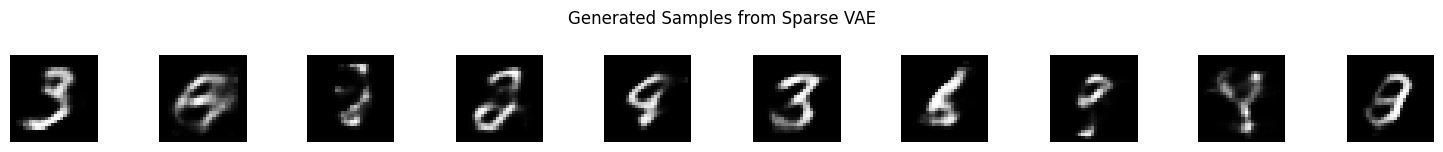

In [19]:
X_generated_sparse = sparse_vae.sample(n_samples)

fig, axes = plt.subplots(1, n_samples, figsize=(n_samples * 1.5, 1.5))

for i in range(n_samples):
    axes[i].imshow(X_generated_sparse[i].reshape(28, 28), cmap='gray')
    axes[i].axis('off')

plt.suptitle('Generated Samples from Sparse VAE')
plt.tight_layout()
plt.savefig('../data/sparse_vae_generated_samples.png', dpi=300)
plt.show()

## 5. Model Comparison

Compare reconstruction results of all four models.


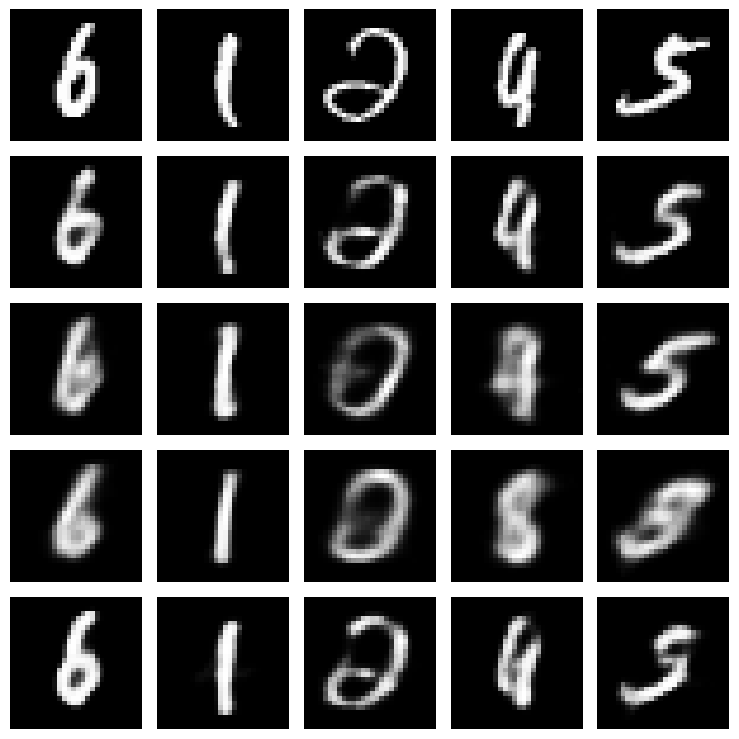

In [20]:
n_compare = 5
indices_compare = np.random.choice(len(X_test), n_compare, replace=False)
X_compare = X_test[indices_compare]

fig, axes = plt.subplots(5, n_compare, figsize=(n_compare * 1.5, 7.5))

for i in range(n_compare):
    axes[0, i].imshow(X_compare[i].reshape(28, 28), cmap='gray')
    axes[0, i].axis('off')
    if i == 0:
        axes[0, i].set_ylabel('Original', fontsize=10)

    axes[1, i].imshow(vae.reconstruct(X_compare[i : i + 1])[0].reshape(28, 28), cmap='gray')
    axes[1, i].axis('off')
    if i == 0:
        axes[1, i].set_ylabel('VAE', fontsize=10)

    axes[2, i].imshow(beta_vae.reconstruct(X_compare[i : i + 1])[0].reshape(28, 28), cmap='gray')
    axes[2, i].axis('off')
    if i == 0:
        axes[2, i].set_ylabel('β-VAE', fontsize=10)

    axes[3, i].imshow(beta_tcvae.reconstruct(X_compare[i : i + 1])[0].reshape(28, 28), cmap='gray')
    axes[3, i].axis('off')
    if i == 0:
        axes[3, i].set_ylabel('β-TC-VAE', fontsize=10)

    axes[4, i].imshow(sparse_vae.reconstruct(X_compare[i : i + 1])[0].reshape(28, 28), cmap='gray')
    axes[4, i].axis('off')
    if i == 0:
        axes[4, i].set_ylabel('Sparse VAE', fontsize=10)

plt.tight_layout()
plt.savefig('../data/model_comparison.png', dpi=300)
plt.show()